In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline

2026-04-11 06:19:53.300464: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775888393.455956      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775888393.500996      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775888393.879343      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775888393.879375      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775888393.879378      16 computation_placer.cc:177] computation placer alr

In [2]:
import kagglehub
path = kagglehub.dataset_download("singhakash/human-activity-recognition-using-smart-phone")
X_train = pd.read_csv(f'{path}/UCI HAR Dataset/train/X_train.txt', sep='\s+', header=None)
Y_train = pd.read_csv(f'{path}/UCI HAR Dataset/train/y_train.txt', sep='\s+', header=None)

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_16/2487954022.py:3: SyntaxWarning: invalid escape sequence '\s'
  X_train = pd.read_csv(f'{path}/UCI HAR Dataset/train/X_train.txt', sep='\s+', header=None)
/tmp/ipykernel_16/2487954022.py:4: SyntaxWarning: invalid escape sequence '\s'
  Y_train = pd.read_csv(f'{path}/UCI HAR Dataset/train/y_train.txt', sep='\s+', header=None)


In [3]:
Y_train.shape

(7352, 1)

In [4]:
x_train_3d = X_train.values.reshape(X_train.shape[0], 1,X_train.shape[1])
y_train_3d = Y_train.values




In [5]:
x_train_3d = x_train_3d.astype('float32')
y_train_3d = y_train_3d.astype('int32')

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
model = Sequential([
    LSTM(units=64, input_shape=(128,561), return_sequences=True),
    Dropout(0.7),

    LSTM(64),
    Dropout(0.7),

    Dense(6, activation='softmax')

])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
              )

2026-04-11 06:20:15.294585: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128, 64)        │       160,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193,670 (756.52 KB)

 Trainable params: 193,670 (756.52 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
print(x_train_3d.shape , y_train_3d.shape)

(7352, 1, 561) (7352, 1)


In [9]:
y_train_3d = y_train_3d - 1
earlu_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint = tf.keras.callbacks.ModelCheckpoint('HAR_LSTM_best.keras', monitor='val_loss', save_best_only=True)

history = model.fit(
    x_train_3d,
    y_train_3d,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    shuffle=True,
    callbacks=checkpoint
    )

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3170 - loss: 1.5774 - val_accuracy: 0.7097 - val_loss: 0.8990
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6001 - loss: 0.9446 - val_accuracy: 0.8525 - val_loss: 0.4668
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7389 - loss: 0.6255 - val_accuracy: 0.9164 - val_loss: 0.3227
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7780 - loss: 0.5114 - val_accuracy: 0.9443 - val_loss: 0.2744
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8099 - loss: 0.4320 - val_accuracy: 0.9177 - val_loss: 0.2644
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8198 - loss: 0.4036 - val_accuracy: 0.9470 - val_loss: 0.1935
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8563 - loss: 0.3462 - val_accuracy: 0.9320 - val_loss: 0.1922
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8693 - loss: 0.3242 - val_accuracy: 0.9463 - val_loss

In [10]:
x_test = pd.read_csv(f'{path}/UCI HAR Dataset/test/X_test.txt', sep='\s+', header=None)
y_test = pd.read_csv(f'{path}/UCI HAR Dataset/test/y_test.txt', sep='\s+', header=None)

x_test_3d = x_test.values.reshape(x_test.shape[0], 1,x_test.shape[1])
y_test_3d = y_test.values
y_test_3d = y_test_3d - 1

loss, accuracy = model.evaluate(x_test_3d, y_test_3d)

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_16/299957587.py:1: SyntaxWarning: invalid escape sequence '\s'
  x_test = pd.read_csv(f'{path}/UCI HAR Dataset/test/X_test.txt', sep='\s+', header=None)
/tmp/ipykernel_16/299957587.py:2: SyntaxWarning: invalid escape sequence '\s'
  y_test = pd.read_csv(f'{path}/UCI HAR Dataset/test/y_test.txt', sep='\s+', header=None)


93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9436 - loss: 0.1893


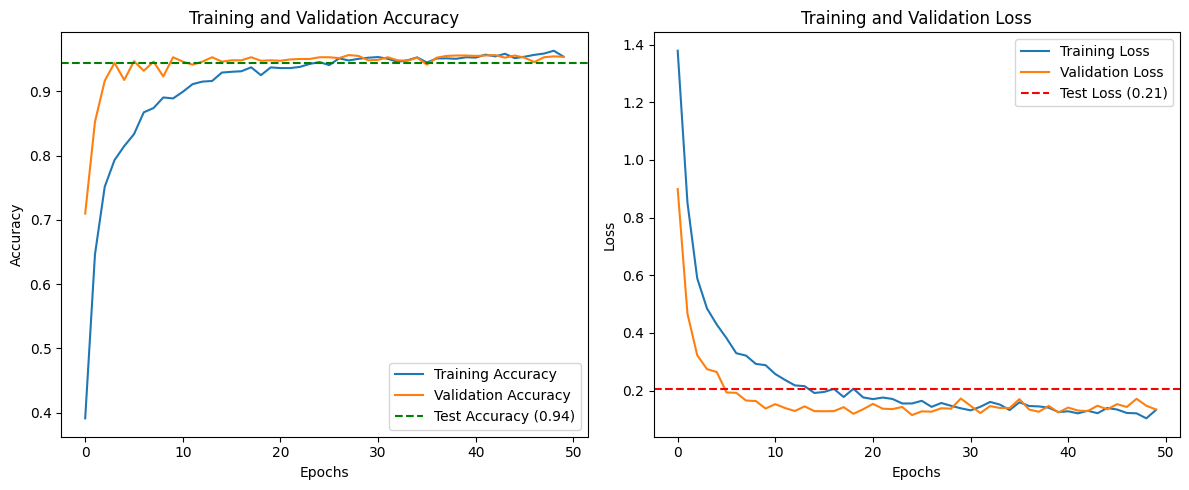

In [11]:
acc = history.history['accuracy']
lossT = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.axhline(y=accuracy, color='g', linestyle='--', label=f'Test Accuracy ({accuracy:.2f})')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, lossT, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.axhline(y=loss, color='r', linestyle='--', label=f'Test Loss ({loss:.2f})')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [12]:
sample = x_test_3d[5]
sample = sample.reshape(1, sample.shape[0], sample.shape[1])
res = model.predict(sample)
res_class = res.argmax()
print(f"the model predicted the clas: {res_class}")
print(f'res: {y_test_3d[5]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
the model predicted the clas: 4
res: [4]


In [13]:
print(res)

[[6.1935393e-06 2.5428274e-06 2.1582125e-07 5.1300218e-03 9.9486017e-01
  7.8894385e-07]]
